In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN
from lokan.utils import ex_round

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# **Optimization/Train code**

In [43]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-3  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            # train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            # test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

# **Dataset** $y = x_0 x_1$

In [80]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
y = x[:, 0] * x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

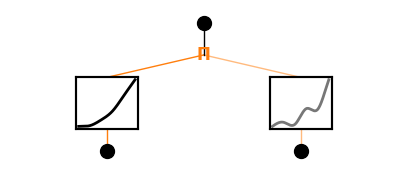

In [84]:
model = loKAN(width=[2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [85]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

Epoch [10/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [20/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [30/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [40/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [50/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [60/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [70/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [80/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [90/100], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [100/100], Train Loss: 0.0000, Test Loss: 0.0000


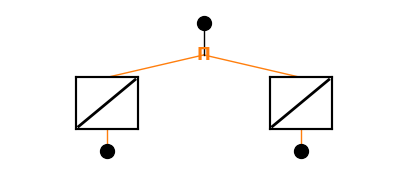

In [86]:
model.plot()

In [87]:
# model.suggest_symbolic(0, 1, 0)

In [88]:
model.auto_symbolic()

fixing (0,0,0) with x, r2=1.0000, c=1
fixing (0,1,0) with x, r2=1.0000, c=1


In [97]:
exprs, syms = model.symbolic_formula(tau_decode=0.05, simplify=True)

In [102]:
print(exprs[0])

1.0*(1.08977719588867*x_1 + 0.000137209377044201)*(0.912377828089291*x_2 + 0.000104250849858545)


In [99]:
expr_rounded = ex_round(exprs[0], 2)

In [101]:
print(expr_rounded)

0.994572022074874*x_1*x_2


In [95]:
expr_rounded = ex_round(expr_rounded, 2)
expr_rounded

0.99*x_1*x_2

In [54]:
syms

[x_1, x_2]

In [96]:
print("Output expression:", exprs[0])
print("Node (0,0):", model.get_sym_node(0, 0))  # input 0
print("Node (0,1):", model.get_sym_node(0, 1))  # input 1
print("Node (1,0):", model.get_sym_node(1, 0))  # output
print("Edge(0,0,0):", model.get_sym_edge(0, 0, 0))  # layer 0, i=0, j=0
print("Edge(0,1,0):", model.get_sym_edge(0, 1, 0))  # layer 0, i=1, j=0
print("sym_expr_edges length:", len(model.sym_expr_edges))
print("sym_expr_nodes length:", len(model.sym_expr_nodes))

Output expression: 1.0*(1.08977719588867*x_1 + 0.000137209377044201)*(0.912377828089291*x_2 + 0.000104250849858545)
Node (0,0): x_1
Node (0,1): x_2
Node (1,0): 1.0*(1.08977719588867*x_1 + 0.000137209377044201)*(0.912377828089291*x_2 + 0.000104250849858545)
Edge(0,0,0): 1.08977719588867*x_1 + 0.000137209377044201
Edge(0,1,0): 0.912377828089291*x_2 + 0.000104250849858545
sym_expr_edges length: 1
sym_expr_nodes length: 2


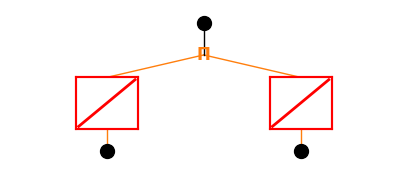

In [103]:
model.plot()

# **Dataset** $y = x_0 x_1$